### EDA and Feature Engineering of Google Play Store Dataset

1. Problem Statement 
    - Today. 1.85 million different apps are availble for users to download. Android users have even more from which to choose, with 2.56 million available through the Google Play Store. Theses apps have come to play a huge role in the way we lives today.
    - Our objective is to find the Most Popular Category, find the app with largest number of installs, the app with largest size etc.

2. The consists of 13 columns and 10841 rows.

##### Steps:
- 1. Data Cleaning 
- 2. Exploratory Data Analysis
- 3. Feature eEngineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")                                 

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')
df.head() 

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.shape

(10841, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [6]:
# Summary of the dataset
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
# We are creating a copy of our original data so that it will not get affected.
df_copy = df.copy()


In [8]:
# Missing Values
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

#### Insights & Observation
- The dataset has missing values

### Data Cleaning

In [18]:
## Converting 'Reviews' column datatype from str to int
df['Reviews'].astype(int)

ValueError: invalid literal for int() with base 10: '3.0M'

##### Unable to convert since there is a '3.0M' value in the 'Reviews' column 

In [16]:
print(df['Reviews'].unique().tolist())

['159', '967', '87510', '215644', '167', '178', '36815', '13791', '121', '13880', '8788', '44829', '4326', '1518', '55', '3632', '27', '194216', '224399', '450', '654', '7699', '61', '118', '192', '20260', '203', '136', '223', '1120', '227', '5035', '1015', '353', '564', '8145', '36639', '158', '591', '117', '176', '295221', '2206', '26', '174531', '1070', '85', '845', '367', '1598', '284', '17057', '129', '542', '10479', '805', '1403', '3971', '534', '7774', '38846', '2431', '6090', '295', '190', '40211', '356', '52530', '116986', '1379', '271920', '736', '7021', '197', '737', '3574', '994', '197136', '142', '15168', '2155', '138', '5414', '21777', '348', '250', '13372', '7880', '3617', '4806', '65786', '31433', '5097', '1754', '2680', '1288', '18900', '49790', '1150', '1739', '32090', '2225', '4369', '8572', '964', '42050', '104', '17934', '601', '36', '187', '182', '30', '134', '74', '113715', '3595', '9315', '75', '38', '26834', '119', '2277', '2280', '184', '9', '77', '35', '364',

In [14]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

##### - Here we observe that in 'Reviews' there are total 10841 values but numeric value are 10840, it means that 1 value is not numeric

In [16]:
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


##### This is the value which is not numeric

In [21]:
# This is only value which is different, so we drop this row because it will not make any difference to the dataset.
# Dropping 1 row does not remove any meaningful information

df_copy = df_copy.drop(df_copy.index[10472])

In [22]:
# Checking after droping that value existing or not
df_copy[~df_copy['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


##### From the output we can see that the value is droped

In [25]:
# Now we can covert "Review" data type to int

df_copy['Reviews']= df_copy['Reviews'].astype(int)

In [ ]:
# checking the "Review" data type
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  str    
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 1.2 MB


##### Inferenece about the "Reviews" column
- It has zero NULL values.
- I have changed its data type to integer.
- I have drop a row which has index 10472 


In [ ]:
## Checking the unique values of 'size' column

df_copy['Size'].unique()

<StringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str

In [ ]:

df_copy['Size'].isnull().sum()

np.int64(0)

##### Size column has zero NULL Values

In [ ]:
#checking unique count
df_copy['Size'].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
552k                     1
885k                     1
1020k                    1
582k                     1
619k                     1
Name: count, Length: 461, dtype: int64

#### Here we found that 'Size' column has "Varies with device" value also

In [35]:
## Size column has values in Megabits and kilobites, so we coverting megabites to kilobites so that all of have a same unit.

df_copy['Size'] = df_copy['Size'].str.replace('M','000')
df_copy['Size'] = df_copy['Size'].str.replace('k','')
df_copy['Size'] = df_copy['Size'].replace('Varies with device',np.nan)
df_copy['Size'] = df_copy['Size'].astype(float)

In [37]:
df_copy['Size']

0        19000.0
1        14000.0
2            8.7
3        25000.0
4            2.8
          ...   
10836    53000.0
10837        3.6
10838        9.5
10839        NaN
10840    19000.0
Name: Size, Length: 10840, dtype: float64

In [38]:
# checking unique values from 'Installs' column
df_copy['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str

In [39]:
df_copy['Price'].unique()

<StringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49',   '$1.29',   '$5.00',  '$13.99', '$299.99', '$379.99',  '$37.99',
  '$18.99', '$389.99',  '$19.90',   '$8.49',   '$1.75',  '$14.00',   '$4.85',
  '$46.99', '$109.99', '$154.99',   '$3.08',   '$2.59',   '$4.80',   '$1.96',
  '$19.40',   '$3.90',   '$4.59',  '$15.46',   '$3.04',   '$4.29',   '$2.60',
   '$3.28',   '$4.60',  '$28.99',   '$2.95',   '$2.90',   '$1.97', '$200.00',
  '$89.99',   '$2.56',  '$30.99',   '$3.61', '$394

#### So after seeing the unique values from "Installs" and "Price" coulumn we observe that
- There are special characters like  '+' ,',' and '$'
- So we remove them

In [40]:
chars_to_remove=['+',',','$']
cols_to_clean=['Installs','Price']

for item in chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols]=df_copy[cols].str.replace(item,'')

In [41]:
df_copy['Installs']

0           10000
1          500000
2         5000000
3        50000000
4          100000
           ...   
10836        5000
10837         100
10838        1000
10839        1000
10840    10000000
Name: Installs, Length: 10840, dtype: str

In [43]:
df_copy['Price']

0        0
1        0
2        0
3        0
4        0
        ..
10836    0
10837    0
10838    0
10839    0
10840    0
Name: Price, Length: 10840, dtype: str

In [ ]:
## Now converting their data type to integer and float

df_copy['Installs'] = df_copy['Installs'].astype('int')

df_copy['Price'] = df_copy['Price'].astype('float')

In [47]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(3), int64(2), str(8)
memory usage: 1.2 MB


In [48]:
## Handling last update feature
df_copy['Last Updated'].unique()

<StringArray>
[   'January 7, 2018',   'January 15, 2018',     'August 1, 2018',
       'June 8, 2018',      'June 20, 2018',     'March 26, 2017',
     'April 26, 2018',      'June 14, 2018', 'September 20, 2017',
       'July 3, 2018',
 ...
  'November 23, 2015',      'June 17, 2012',  'February 27, 2015',
  'December 18, 2013',   'February 6, 2012',  'November 25, 2014',
       'May 19, 2016',   'January 20, 2014',  'February 16, 2014',
     'March 23, 2014']
Length: 1377, dtype: str

In [50]:
## Changing date format
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])
df_copy['Last Updated']

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10836   2017-07-25
10837   2018-07-06
10838   2017-01-20
10839   2015-01-19
10840   2018-07-25
Name: Last Updated, Length: 10840, dtype: datetime64[us]

In [51]:
# Now extracting day, month, year from the Date
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

In [52]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  str           
 1   Category        10840 non-null  str           
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  str           
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  str           
 9   Genres          10840 non-null  str           
 10  Last Updated    10840 non-null  datetime64[us]
 11  Current Ver     10832 non-null  str           
 12  Android Ver     10838 non-null  str           
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year            10

## Exploratory Data Analysis - EDA

In [53]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [55]:
# checking is there any duplicate "App" in the column
df_copy.duplicated('App').sum()

np.int64(1181)

#### Observation: The Dataset has 1181 duplicate records

In [56]:
# Now we are droping the duplicate records

df_copy= df_copy.drop_duplicates(subset='App',keep='first')

In [58]:
# Now checking the number of rows
df_copy.shape

(9659, 16)

In [68]:
# bifurcating numerical and categorical features
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'str']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype =='str']

# print column
print('We have {} numerical features : {}'.format(len(numeric_features),numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features),categorical_features))



We have 9 numerical features : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']
We have 7 categorical features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


In [ ]:
## proportion of count data on categorical columns
#  % distribution of each value present in a each category
# % distribution = understand your data before modeling — imbalance, dominance, quality issues

for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('---------------------------------')
     

App
ROBLOX                                               0.083018
CBS Sports App - Scores, News, Stats & Watch Live    0.073794
Duolingo: Learn Languages Free                       0.064570
Candy Crush Saga                                     0.064570
8 Ball Pool                                          0.064570
                                                       ...   
Sya9a Maroc - FR                                     0.009224
Fr. Mike Schmitz Audio Teachings                     0.009224
Parkinson Exercices FR                               0.009224
The SCP Foundation DB fr nn5n                        0.009224
iHoroscope - 2018 Daily Horoscope & Astrology        0.009224
Name: proportion, Length: 9660, dtype: float64
---------------------------------
Category
FAMILY                 18.190204
GAME                   10.552532
TOOLS                   7.776035
MEDICAL                 4.270824
BUSINESS                4.243151
PRODUCTIVITY            3.911078
PERSONALIZATION         3.

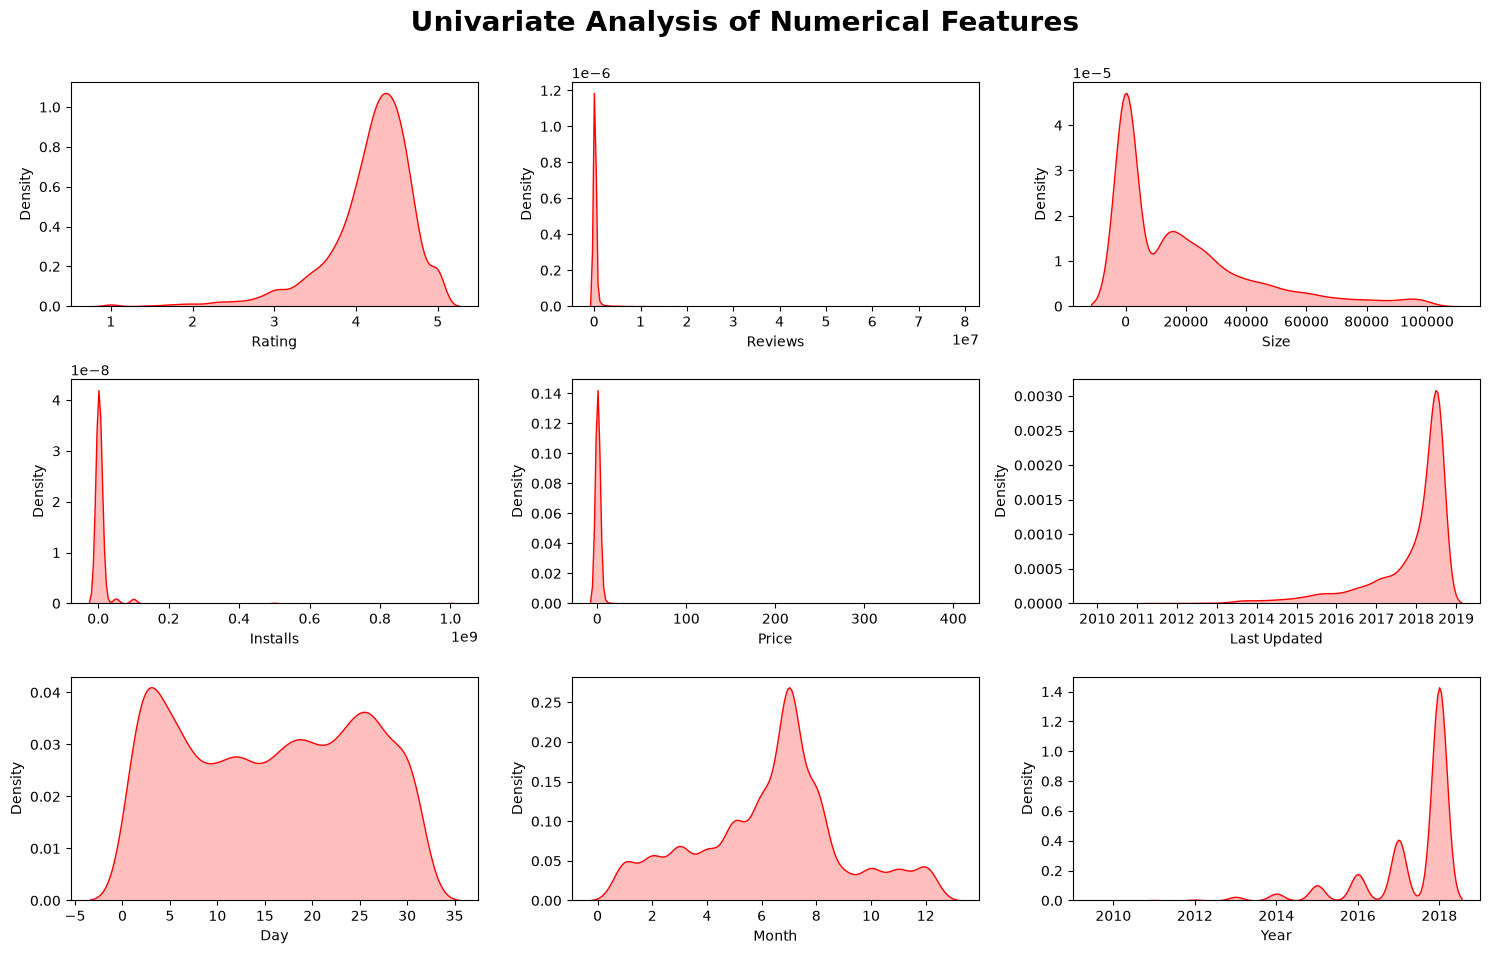

In [ ]:

plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical Features',fontsize=20, fontweight='bold', y=1.)   # y=1. --># title position (top)

for i in range(0,len(numeric_features)):
    plt.subplot(5,3, i+1)                                                       #plt.subplot(5, 3, i+1)   # 5 rows, 3 columns = 15 plots total
    sns.kdeplot(x=df_copy[numeric_features[i]], shade=True, color='r')                                    # i+1 = position of current plot (1 to 15)
    plt.xlabel(numeric_features[i])                                             #kernel density estimator
    plt.tight_layout()

#### Observations
- Rating and Year is left skewed
- Reviews, size, Installs and Price are right skewed

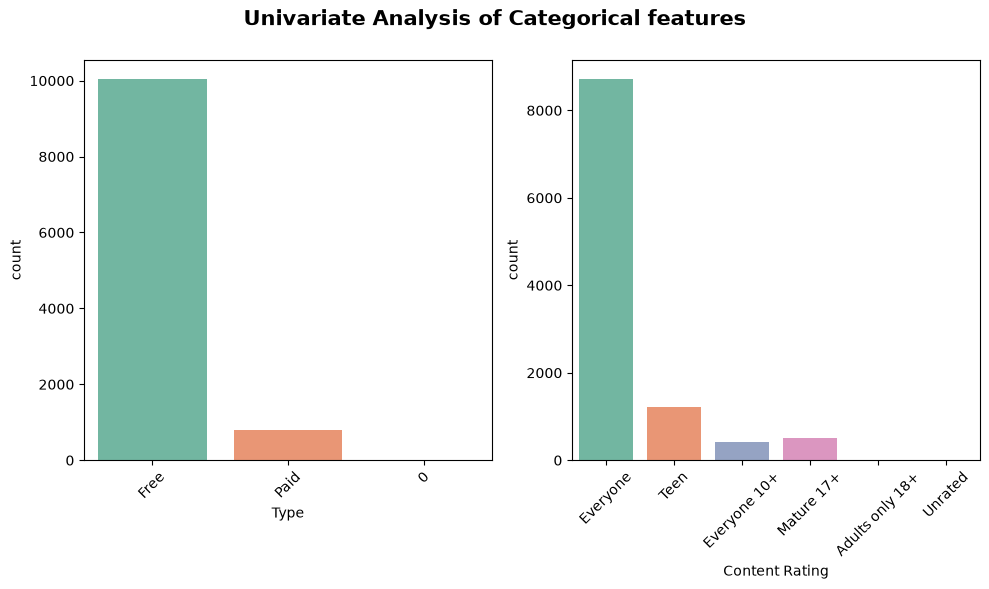

In [ ]:
# Categorical Columns

plt.figure(figsize=(10,10))
plt.suptitle('Univariate Analysis of Categorical features',fontsize=15, fontweight='bold',y=1.)
category = ['Type','Content Rating']
for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[category[i]], palette='Set2')            # palette='Set2')----->color scheme for the bars
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

### Which is the most popular app category?

<Axes: >

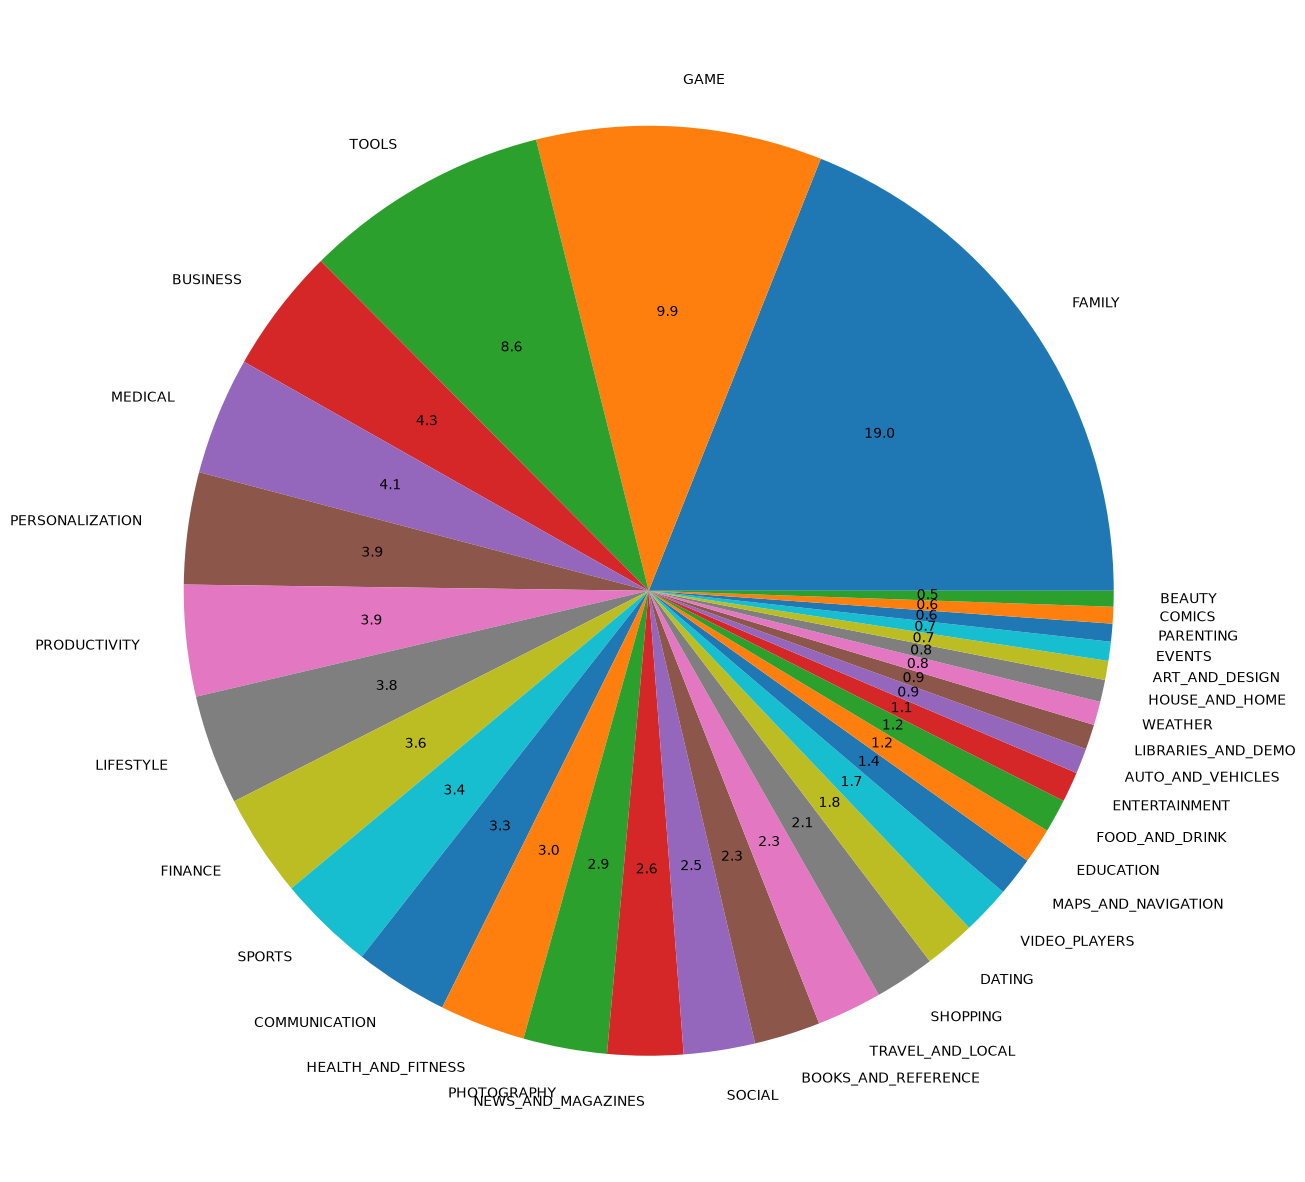

In [98]:
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'],figsize=(15,16),autopct='%1.1f')

### Observations:
1. There are more kinds of apps in playstore which are under category of family, games and tools.
2. Beauty, comics, arts and weather kinds of apps are very less in playstore.

### Which are top 10 app category?

In [112]:
# creating a DataFrame of apps on the basis of category
category = pd.DataFrame(df_copy['Category'].value_counts())  
category.rename(columns = {'Category':'Count'}, inplace=True)    
category


,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


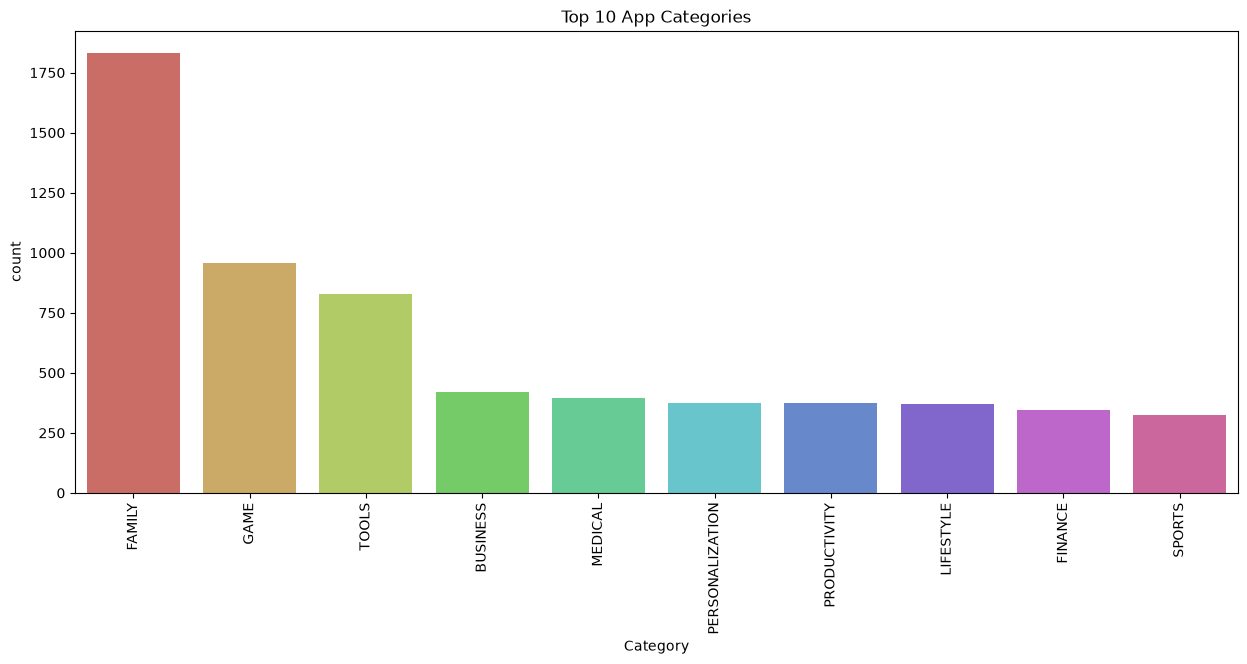

In [119]:
# creating a bar plot of top 10 category

plt.figure(figsize=(15,6))
sns.barplot(x=category.index[0:10], y='count', data= category[:10], palette='hls')
plt.title('Top 10 App Categories')
plt.xticks(rotation=90)
plt.show()


#### Insights
1. Family category has the most number of apps with 19% of apps belonging to it, followed by Games category which has 9.9% of the apps.
2. Least number of apps belong to the beauty category with less than 1% of the total apps belonging to it.

### Which category has largest number of installations?

Text(0.5, 1.0, 'Most Popular Categories in Playstore')

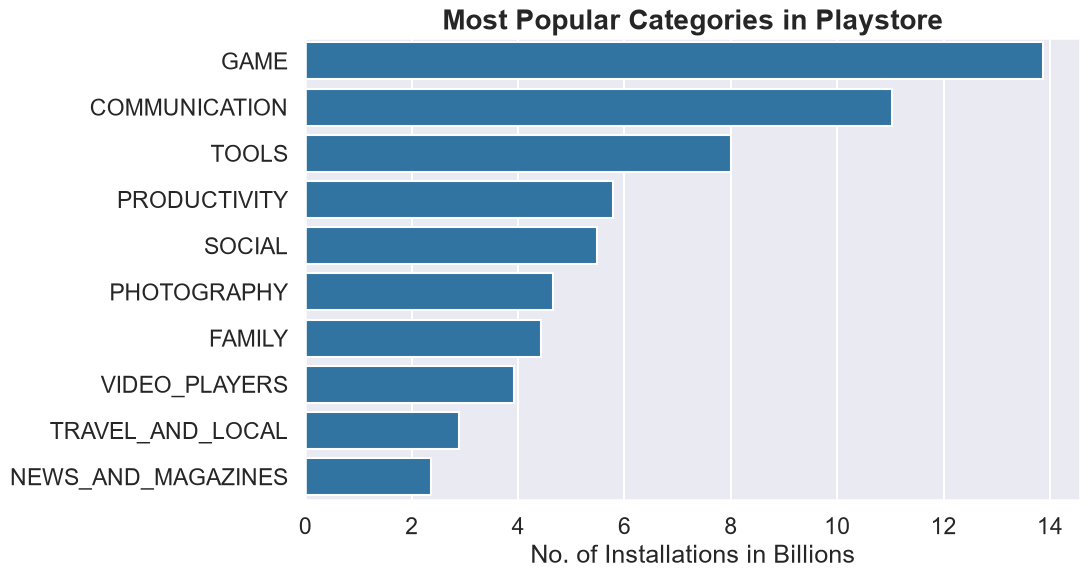

In [137]:
df_cat_installs = df_copy.groupby(['Category'])['Installs'].sum().sort_values(ascending=False).reset_index()
df_cat_installs.Installs = df_cat_installs.Installs/1000000000   #converting into billions
df2 = df_cat_installs.head(10)
plt.figure(figsize=(10,6))
sns.set_context("talk")
sns.set_style("darkgrid")

ax = sns.barplot(x='Installs', y='Category', data=df2)
ax.set_xlabel('No. of Installations in Billions')
ax.set_ylabel('')
ax.set_title('Most Popular Categories in Playstore', size=20, fontweight ='bold',y=1.)

### Insights
1. Out of all the category "GAME" has the most number of installations.
2. With almost 35 Billion installations "GAME" is the popular category in Google App Store. 

### What are the Top 5 most installed apps in each popular categories? 

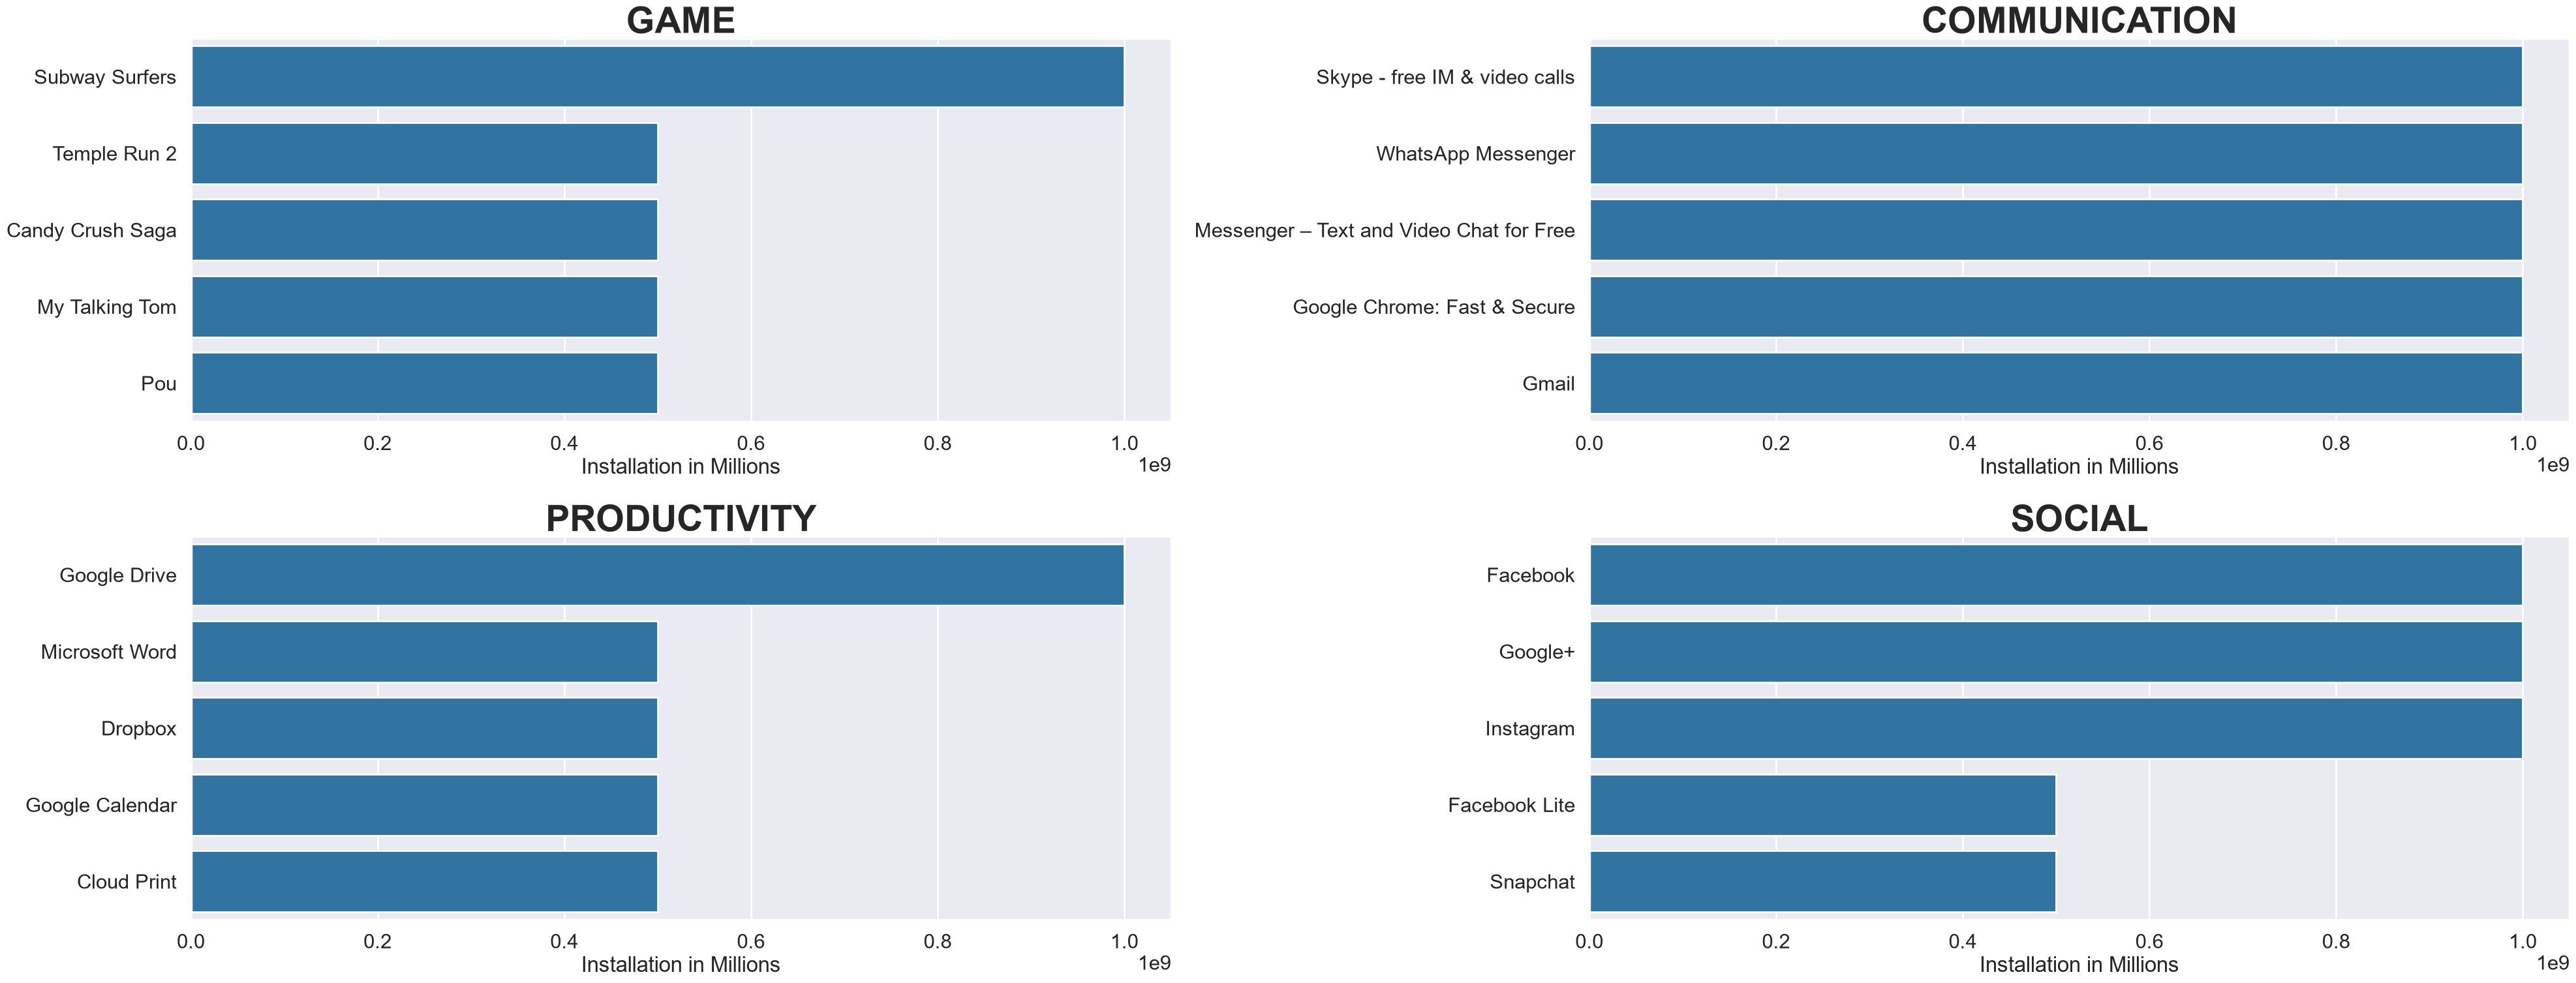

In [146]:
dfa = df_copy.groupby(['Category' ,'App'])['Installs'].sum().reset_index()
dfa = dfa.sort_values('Installs', ascending = False)
apps = ['GAME', 'COMMUNICATION', 'PRODUCTIVITY', 'SOCIAL' ]
sns.set_context("poster")
sns.set_style("darkgrid")

plt.figure(figsize=(40,30))

for i,app in enumerate(apps):
    df2 = dfa[dfa.Category == app]
    df3 = df2.head(5)
    plt.subplot(4,2,i+1)
    sns.barplot(data= df3,x= 'Installs' ,y='App' )
    plt.xlabel('Installation in Millions')
    plt.ylabel('')
    plt.title(app,size = 40,fontweight='bold')
    
plt.tight_layout()
plt.subplots_adjust(hspace= .3)
plt.show()

##### **Insights**

1. Most popular game is Subway Surfers.
2. Most popular commuication app is Skype.
3. Most popular productivity app is Google Drive.
4. Most popular social app is Facebook.

### How many apps are there on Google Play Store which get 5 ratings?

In [150]:
rating = df_copy.groupby(['Category','Installs','App'])['Rating'].sum().sort_values(ascending=False).reset_index()

toprating_apps = rating[rating.Rating==5.0]
print("Number of 5 rated apps :", toprating_apps.shape[0])
toprating_apps.head()

Number of 5 rated apps : 271


,Category,Installs,App,Rating
0,FAMILY,10,DN Employee,5.0
1,FAMILY,10,Chronolink DX,5.0
2,MEDICAL,500,FHR 5-Tier 2.0,5.0
3,HEALTH_AND_FITNESS,10,CB Fit,5.0
4,MEDICAL,100,Zen Leaf,5.0


##### **Insights**

1. There are 271 five rated apps on Google Play Store.
2. Top most is 'DN Employee' app from Family category